In [5]:

import numpy as np
import matplotlib.pyplot as plt

# Set environment variables
import os


os.environ["SCAL_TYPE"] = "complex"
os.environ["PRECISION"] = "single"
os.environ["MY_NUMBA_TARGET"] = "numba"

# Add cle_fun to PYTHON_PATH
import sys
sys.path.append("../../clonscal")

In [6]:
import numpy as np
from simulation.config import Config
from simulation.cl_simulation import ComplexLangevinSimulation
from src.obs_kernels import (
    n_moment_kernel, 
    dse_n_moment_kernel,
    abs_drift
)
from tqdm import tqdm
from simulation.gpu_handler import GPU_handler
from src.numba_target import use_cuda
import src.scal as scal
from src.utils import (
    update_histogram_complex, 
    update_histogram_real,
    gaussian_modified_density_drift_kernel, 
    noise_kernel_rotated,
    calculate_stats_complex
)

from src.numba_target import my_act_parallel_loop
from numba import cuda

Using single precision
Using C^1
Using Numba


define a configuration with desired parameters. see simulation.config.py for defaults. Based on the config, define a simulation object

In [3]:
config = Config(dims = [1], sigma=1, interaction=1, trajs = 2, steps = int(1e5), dt = 1e-4)
sim = ComplexLangevinSimulation(config)

Register observables into the object. This defines ObservableTracker instances

In [10]:
sim.register_observable('1_moment', obs_kernel=n_moment_kernel, const_param={"order" : 1},  langevin_history=True, thermal_time=5, auto_corr=1.0)
sim.register_observable('2_moment', obs_kernel=n_moment_kernel, const_param={"order" : 2},  langevin_history=True, thermal_time=5, auto_corr=1.0)

These can not be addressed via

In [11]:
sim.trackers

{'1_moment': <simulation.observables.ObservableTracker at 0x7f5053d7dd20>,
 '2_moment': <simulation.observables.ObservableTracker at 0x7f50b917d0f0>}

The trackers are independent from each other. The observable carries information about all the trajectories, see shape of the arrays

In [12]:
sim.trackers["1_moment"].__dict__

{'obs_name': '1_moment',
 'shape': (2,),
 'obs_kernel': <function src.obs_kernels.n_moment_kernel(idx, phi0, result, order, langevin_time, adims, meas_time)>,
 'langevin_history': True,
 'const_param': {'order': 1},
 'init_history_size': 100001,
 'thermal_time': 5,
 'auto_corr': 1.0,
 'order': 1,
 '_sim_instance': <simulation.cl_simulation.ComplexLangevinSimulation at 0x7f50b917c790>,
 'equilibrated_trajs': array([False, False]),
 'meas_time': array([-1., -1.], dtype=float32),
 'result': array([0.+0.j, 0.+0.j], dtype=complex64),
 'history_result': array([0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       dtype=complex64),
 'history_meas_times': array([0., 0., 0., ..., 0., 0., 0.], dtype=float32),
 'kernel_bridge': <src.utils.KernelBridge at 0x7f5053d7f850>,
 'stats': <src.utils.RollingStats at 0x7f5053d7f7f0>,
 'rolling_mean': array([0.+0.j, 0.+0.j], dtype=complex64),
 'rolling_sqr_mean_real': array([0., 0.], dtype=float32),
 'rolling_sqr_mean_imag': array([0., 0.], dtype=flo

Once a simulation steps is performed

In [13]:
sim.step()

the global degree of freedom sim.phi is updated according to the langevin equation. It stores the values for all the trajectories. 

In [14]:
sim.phi0

array([-0.01405731+0.j, -0.00388564+0.j], dtype=complex64)

After a step, we have to decide whether observables are to be calculated, depending on tracker.thermal_time and tracker.auto_corr.  
Every trajectory is associated with a boolean that allows or blocks calculation. These are set to False in the beginning

In [15]:
sim.trackers["1_moment"].equilibrated_trajs

array([False, False])

We could call tracker.compute(), but all trajectories will be ignored. Their result is unchanged (zero)

In [16]:
sim.trackers["1_moment"].compute()
print(sim.trackers["1_moment"].result)
print(sim.trackers["1_moment"].counter)

[0.+0.j 0.+0.j]
[0 0]


only after a certain number of steps will the trajs be allowed to be observed. To (un)block the trajs, we call tracker.mark_equilibrated_trajs

In [17]:
for _ in range(int(1e5)):
    sim.step()
    for name, tr in sim.trackers.items():
        tr.mark_equilibrated_trajs()

KeyboardInterrupt: 

In [ ]:
sim.trackers["1_moment"].equilibrated_trajs

array([ True,  True])

After computation, the result is stored in a buffer and the rolling stats are updated.

In [ ]:
sim.trackers["1_moment"].compute()
sim.trackers["1_moment"].mark_equilibrated_trajs()
sim.trackers["1_moment"].equilibrated_trajs
print(f"Result buffer: {sim.trackers['1_moment'].result}")
print(f"Counter: {sim.trackers['1_moment'].counter}")
print(f"Rolling mean: {sim.trackers['1_moment'].rolling_mean}")
print(f"Rolling sq mean: {sim.trackers['1_moment'].rolling_sqr_mean_real}")
print()

Result buffer: [0.40605822+0.j 0.39123407+0.j]
Counter: [1 1]
Rolling mean: [0.40605822+0.j 0.39123407+0.j]
Rolling sq mean: [0.16488329 0.1530641 ]



The full loop looks someting like this

In [ ]:
for _ in range(int(1e5)):
    sim.step()
    for name, tr in sim.trackers.items():
        tr.mark_equilibrated_trajs()
        tr.compute()

print(f"Result buffer: {sim.trackers['1_moment'].result}")
print(f"Counter: {sim.trackers['1_moment'].counter}")
print(f"Rolling mean: {sim.trackers['1_moment'].rolling_mean}")
print(f"Rolling sq mean: {sim.trackers['1_moment'].rolling_sqr_mean_real}")
print()

Result buffer: [-0.46602854+0.j -1.4637948 +0.j]
Counter: [10 10]
Rolling mean: [-3.6951525 +0.j  0.26762617+0.j]
Rolling sq mean: [7.0568004 5.5083423]



To combine the rolling stats over different observables, call sim.finish()

In [ ]:
sim.finish()
sim.trackers["1_moment"].rolling_mean

(-3.4275265+0j)

from here stats can be calculated using utils.calculate_stats_complex

In [ ]:
from src.utils import calculate_stats_complex
rolling_mean = sim.trackers["1_moment"].rolling_mean
rolling_sqr_mean_real = sim.trackers["1_moment"].rolling_sqr_mean_real
rolling_sqr_mean_imag = sim.trackers["1_moment"].rolling_sqr_mean_imag
counter = sim.trackers["1_moment"].counter
mean, sem_real, sem_imag = calculate_stats_complex(rolling_mean, rolling_sqr_mean_real, rolling_sqr_mean_imag, counter)

print(f"First moment: {np.round(mean, 5)} pm {np.round(sem_real, 5)}")

First moment: (-0.17138+0j) pm 0.17304


The code is optimized for parallel execution of multiple trajectories

In [ ]:
config = Config(dims = [1], sigma=1, interaction=1, trajs = int(1e4), steps = int(1e5), dt = 1e-4)
sim = ComplexLangevinSimulation(config)

sim.register_observable('1_moment', obs_kernel=n_moment_kernel, const_param={"order" : 1},  langevin_history=True, thermal_time=2, auto_corr=1.0)
sim.register_observable('2_moment', obs_kernel=n_moment_kernel, const_param={"order" : 2},  langevin_history=True, thermal_time=2, auto_corr=1.0)

for _ in tqdm(range(sim.steps)):
    sim.step()
    for name, tr in sim.trackers.items():
        tr.mark_equilibrated_trajs()
        tr.compute()
sim.finish()

100%|██████████| 100000/100000 [00:26<00:00, 3764.78it/s]


In [17]:
# scipy routines
import numpy as np
from scipy.integrate import quad
from numba import jit

def n_moment(x, order):
    return x**order

# define rho and R
@jit
def action(x, sigma, lamb): return sigma/2*x**2+lamb/4*x**4

@jit
def rho(x, sigma, lamb): return np.exp(-action(x, sigma, lamb))

# define partition sums
def z_rho(sigma, lamb): 
    real_part = quad(lambda x: np.real(rho(x, sigma, lamb)), -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(rho(x, sigma, lamb)), -np.inf, np.inf)[0]
    return real_part+1j*imag_part


# define exp val of n_moment wrt rho
@np.vectorize
def n_moment_rho(order, sigma, lamb):
    real_part = quad(lambda x: np.real(rho(x, sigma, lamb)*n_moment(x, order)), 
                     -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(rho(x, sigma, lamb)*n_moment(x, order)), 
                     -np.inf, np.inf)[0]
    out = real_part + 1j*imag_part
    return out / z_rho(sigma, lamb)

In [ ]:
rolling_mean = sim.trackers["1_moment"].rolling_mean
rolling_sqr_mean_real = sim.trackers["1_moment"].rolling_sqr_mean_real
rolling_sqr_mean_imag = sim.trackers["1_moment"].rolling_sqr_mean_imag
counter = sim.trackers["1_moment"].counter
mean, sem_real, sem_imag = calculate_stats_complex(rolling_mean, rolling_sqr_mean_real, rolling_sqr_mean_imag, counter)

print(f"First moment: [{np.round(mean-sem_real, 5)}; {np.round(mean+sem_real, 5)}]")
print(f"scipy: {n_moment_rho(1, sim.sigma, sim.interaction)}")

First moment: [(-0.00779+0j); (-0.00297+0j)]
scipy: 0j


In [ ]:
rolling_mean = sim.trackers["2_moment"].rolling_mean
rolling_sqr_mean_real = sim.trackers["2_moment"].rolling_sqr_mean_real
rolling_sqr_mean_imag = sim.trackers["2_moment"].rolling_sqr_mean_imag
counter = sim.trackers["2_moment"].counter
mean, sem_real, sem_imag = calculate_stats_complex(rolling_mean, rolling_sqr_mean_real, rolling_sqr_mean_imag, counter)

print(f"Second moment: [{np.round(mean-sem_real, 5)}; {np.round(mean+sem_real, 5)}]")
print(f"scipy: {n_moment_rho(2, sim.sigma, sim.interaction)}")

Second moment: [(0.46649+0j); (0.47043+0j)]
scipy: (0.4679199169736833+0j)


## Trajectory history
Due to adaptive step size, different trajectories have different langevin dynamics. This means, that one trajectory may sample in a region with small drift magnitudes while another may encounter huge drifts. The first trajectory will have ada_step = 1 and the second ada_step << 1.  
If we want to study langevin dynamics - the evolution of an observable as langevin time progresses, we could study the average over multiple trajectories. These however may diverge as mentioned above.  


In [21]:

import numpy as np
import matplotlib.pyplot as plt

# Set environment variables
import os


os.environ["SCAL_TYPE"] = "complex"
os.environ["PRECISION"] = "single"
os.environ["MY_NUMBA_TARGET"] = "numba"

# Add cle_fun to PYTHON_PATH
import sys
sys.path.append("../../clonscal")

In [22]:
import numpy as np
from simulation.config import Config
from simulation.cl_simulation import ComplexLangevinSimulation
from src.obs_kernels import (
    n_moment_kernel, 
    dse_n_moment_kernel,
    abs_drift
)
from tqdm import tqdm
from simulation.gpu_handler import GPU_handler
from src.numba_target import use_cuda
import src.scal as scal
from src.utils import (
    update_histogram_complex, 
    update_histogram_real,
    gaussian_modified_density_drift_kernel, 
    noise_kernel_rotated,
    calculate_stats_complex
)

from src.numba_target import my_act_parallel_loop
from numba import cuda

In [23]:
config = Config(dims = [1], sigma=1, mean_ds_max = 50, interaction=1, trajs = int(1e3), steps = int(1e4), dt = 1e-4)
sim = ComplexLangevinSimulation(config)
sim.register_observable('1_moment', obs_kernel=n_moment_kernel, const_param={"order" : 1},  langevin_history=True, thermal_time=0, auto_corr=5e-5)
sim.register_observable('2_moment', obs_kernel=n_moment_kernel, const_param={"order" : 2},  langevin_history=True, thermal_time=0, auto_corr=5e-5)

In [24]:
min_real = 0
max_real = sim.dt*sim.steps
for _ in tqdm(range(sim.steps)):
    sim.step()
    for name, tr in sim.trackers.items():
        tr.mark_equilibrated_trajs()
        tr.compute()
        tr.update()
        # for traj_idx, (marked, meas, res) in enumerate(zip(tr.equilibrated_trajs, sim.trackers["2_moment"].meas_time, sim.trackers["2_moment"].result)):
        #     if marked:
                # if min_real < meas < max_real:

                #     # print(f"traj {traj_idx}: marked")
                #     bin_mt = int((meas - min_real) / (max_real - min_real) * sim.steps)
                #     bin_mt = min(bin_mt, sim.steps - 1)  # Ensure within range

                #     tr.history_counter[bin_mt] += 1
                #     tr.history_result[bin_mt] += res
                #     tr.history_meas_times[bin_mt] += meas
sim.finish()

100%|██████████| 10000/10000 [00:41<00:00, 243.86it/s]


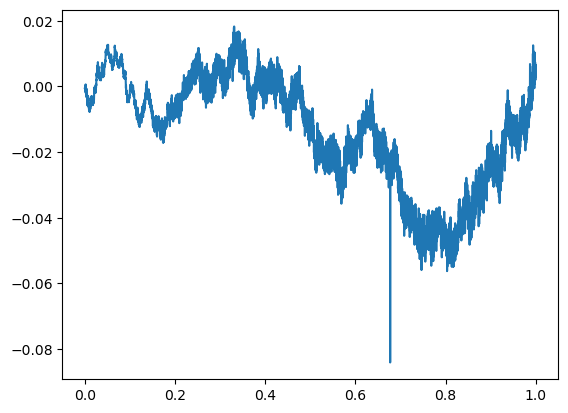

In [11]:
plt.plot(sim.trackers["1_moment"].history_meas_times, sim.trackers["1_moment"].history_result)

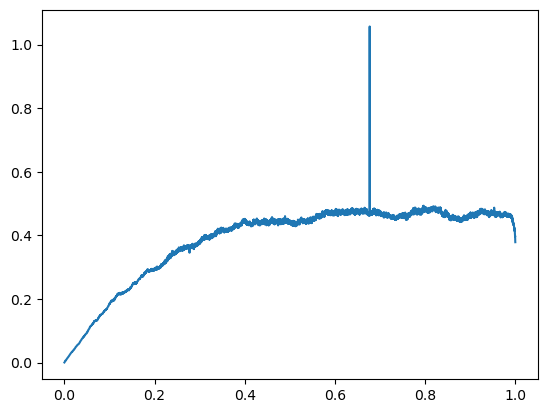

In [26]:
plt.plot(sim.trackers["2_moment"].history_meas_times, sim.trackers["2_moment"].history_result)

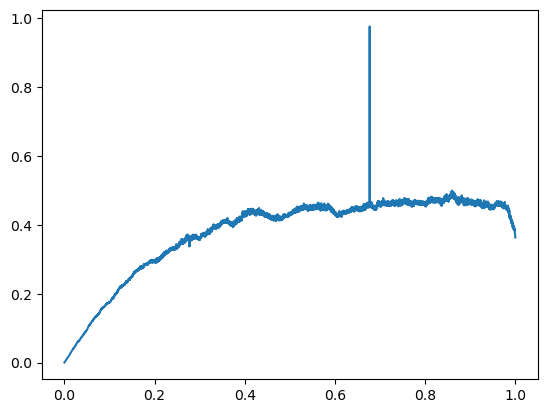

In [12]:
plt.plot(sim.trackers["2_moment"].history_meas_times, sim.trackers["2_moment"].history_result)

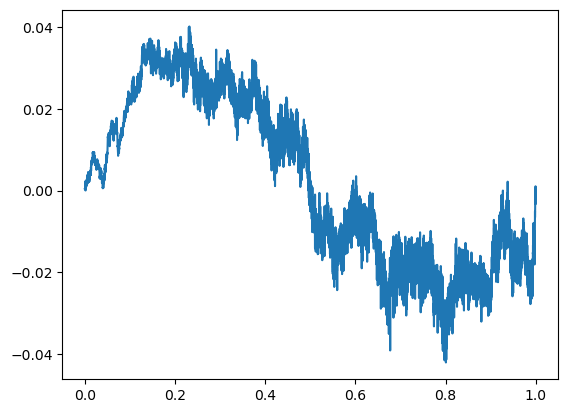

In [13]:
mask = sim.trackers["1_moment"].history_counter > 0

dat = sim.trackers["1_moment"].history_result[mask]/sim.trackers["1_moment"].history_counter[mask]
lt = sim.trackers["1_moment"].history_meas_times[mask]/sim.trackers["1_moment"].history_counter[mask]

plt.plot(lt, dat)

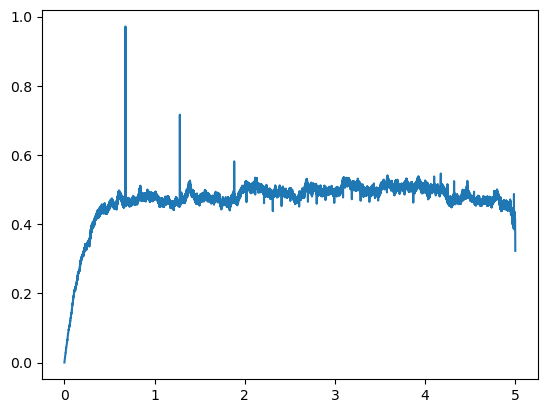

In [28]:
mask = sim.trackers["2_moment"].history_counter > 0

dat = sim.trackers["2_moment"].history_result[mask]/sim.trackers["2_moment"].history_counter[mask]
lt = sim.trackers["2_moment"].history_meas_times[mask]/sim.trackers["2_moment"].history_counter[mask]

plt.plot(lt, dat)

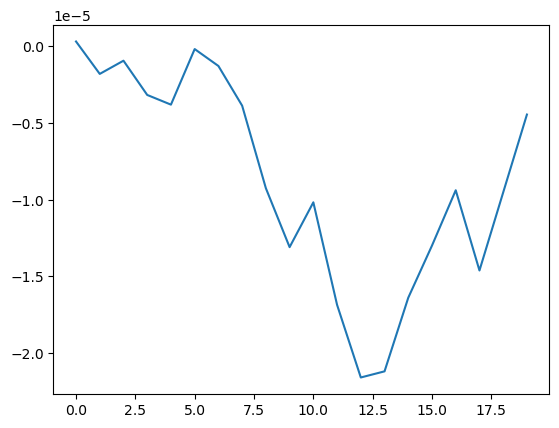

In [733]:
mask = sim.trackers["2_moment"].history_counter > 0
sim.trackers["2_moment"].history_counter = sim.trackers["2_moment"].history_counter[mask]
sim.trackers["2_moment"].history_result = sim.trackers["2_moment"].history_result[mask]
# sim.trackers["2_moment"].history_meas_times = sim.trackers["2_moment"].history_meas_times[mask]

sim.trackers["2_moment"].history_result /= sim.trackers["2_moment"].history_counter
# sim.trackers["2_moment"].history_meas_times /= sim.trackers["2_moment"].history_counter

plt.plot(sim.trackers["2_moment"].history_result.real)

In [62]:

print()

In [442]:
sim.trackers["2_moment"].history_meas_times

array([9.9999997e-05, 3.9999999e-04, 6.9999998e-04, 8.9999998e-04,
       1.1999998e-03, 1.4999997e-03], dtype=float32)

In [276]:
sim.trackers["2_moment"].history_result.shape

(467,)

In [66]:
sim.trackers["2_moment"].history_counter

array([2.+0.j, 2.+0.j, 2.+0.j, 2.+0.j, 2.+0.j, 2.+0.j], dtype=complex64)

In [64]:
sim.trackers["2_moment"].history_counter[:100]

array([2.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 2.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 2.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 2.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 2.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 2.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j], dtype=complex64)

In [60]:
import numpy as np
for lt in np.arange(0, np.max(sim.langevin_time), sim.dt):
    bin_mt = int((lt - min_real) / (max_real - min_real) * sim.steps)
    count = (sim.langevin_time > lt).sum()
    print(bin_mt)

0
1
2
3
4
5
6
6
8
9
10
11
12
13
13
15
16
17
18
19
20
21
22
23
24
25
26
27
27
29
30


In [639]:
sim.trackers["2_moment"].history_result[:100]

array([8.5571322e-05+0.j, 4.2785661e-05+0.j, 1.2593034e-03+0.j,
       2.3594170e-03+0.j, 8.7557908e-04+0.j, 4.1595292e-03+0.j,
       7.3952265e-03+0.j, 6.1283461e-03+0.j, 5.4113809e-03+0.j,
       1.8927604e-03+0.j, 7.5186710e-03+0.j, 2.8129553e-03+0.j,
       9.1227945e-03+0.j, 3.1549195e-03+0.j, 5.9027886e-03+0.j,
       1.3739344e-03+0.j, 1.7146828e-03+0.j, 1.5002300e-03+0.j,
       2.0555547e-03+0.j, 1.6075182e-03+0.j, 1.7603798e-03+0.j,
       1.4922125e-03+0.j, 1.6062522e-03+0.j, 1.4942434e-03+0.j,
       1.3615896e-03+0.j, 1.6214071e-03+0.j, 1.8497594e-03+0.j,
       1.7042711e-03+0.j, 1.4230378e-03+0.j, 0.0000000e+00+0.j,
       0.0000000e+00+0.j, 0.0000000e+00+0.j, 0.0000000e+00+0.j,
       0.0000000e+00+0.j, 0.0000000e+00+0.j, 0.0000000e+00+0.j,
       0.0000000e+00+0.j, 0.0000000e+00+0.j, 0.0000000e+00+0.j,
       0.0000000e+00+0.j, 0.0000000e+00+0.j, 0.0000000e+00+0.j,
       0.0000000e+00+0.j, 0.0000000e+00+0.j, 0.0000000e+00+0.j,
       0.0000000e+00+0.j, 0.0000000e+00+

In [9]:
from src.utils import update_history_kernel
my_act_parallel_loop(update_history_kernel, sim.trackers["2_moment"].equilibrated_trajs, 
                     sim.trajs, sim.trackers["2_moment"].result, sim.trackers["2_moment"].history_result, sim.steps, 0, sim.dt*sim.steps)

In [283]:
sim.trackers["2_moment"].history_result[:10]

array([1.1569028e-05+0.j, 4.9986607e+01+0.j, 4.9986431e+01+0.j,
       4.9986664e+01+0.j, 4.9987320e+01+0.j, 4.9987644e+01+0.j,
       0.0000000e+00+0.j, 0.0000000e+00+0.j, 0.0000000e+00+0.j,
       0.0000000e+00+0.j], dtype=complex64)

array([0.0002, 0.0002], dtype=float32)

array([1.e-04, 1.e-04], dtype=float32)

In [ ]:
sim.step()
sim.trackers["2_moment"].mark_equilibrated_trajs()
sim.trackers["2_moment"].compute()
sim.trackers["2_moment"].update()
print(sim.trackers["2_moment"].meas_time)
print(sim.trackers["2_moment"].result)

[0.00759999 0.00759999]
[0.01157198-0.j 0.00055925-0.j]


In [ ]:
print(sim.langevin_time[0]-sim.trackers["2_moment"].meas_time[0])

9.999983e-05
